# 🏎️ F1 Pit Stop Prediction — Notebook 1: Exploratory Data Analysis
**Kaggle Playground Series S6E5**  
Goal: Predict whether a driver will pit on the **next lap** (binary classification, AUC metric)

## 0. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('data')

train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

Train shape: (439140, 16)
Test shape:  (188165, 15)


## 1. First Look

In [3]:
train.head(10)

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0000,8,78.4910,-7.5640,21.0190,0.7143,5.0000,1.0000
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0000,4,75.0950,-32.6170,-223.2070,0.3462,-3.0000,0.0000
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0000,13,70.9450,-7.5400,-100.5290,0.8194,3.0000,1.0000
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0000,7,94.3610,-7.3240,-7.3240,0.0769,0.0000,0.0000
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0000,2,107.8780,8.9650,-14.1390,0.3611,3.0000,0.0000
5,5,D012,HARD,Saudi Arabian Grand Prix,2022,0,35,2,26.0000,5,93.7340,-9.8780,-98.0410,0.5000,-3.0000,1.0000
6,6,D104,MEDIUM,Belgian Grand Prix,2023,0,23,2,16.0000,11,114.9370,-0.1810,-11.9040,0.3333,0.0000,0.0000
7,7,D082,HARD,United States Grand Prix,2022,0,41,3,9.0000,1,100.2110,-10.2920,-53.7990,0.5694,0.0000,0.0000
8,8,BEL,MEDIUM,Italian Grand Prix,2022,0,4,1,4.0000,12,87.9730,10.7450,-32.9290,0.1111,-9.0000,0.0000
9,9,YAM,MEDIUM,Hungarian Grand Prix,2023,0,2,1,2.0000,8,84.7260,-6.6690,-6.6690,0.0282,0.0000,0.0000


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [5]:
train.describe(include='all')

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.0000,439140,439140,439140,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000,439140.0000
unique,NaN,887,5,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MAS,MEDIUM,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1682,211141,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,219569.5000,NaN,NaN,NaN,2023.5235,0.1361,23.1059,1.7891,14.1582,9.6303,90.9487,-3.7700,-25.7218,0.3377,0.1015,0.1990
std,126768.9429,NaN,NaN,NaN,1.0249,0.3429,16.9583,0.9502,9.8013,5.2788,19.7728,43.9458,54.7666,0.2533,4.0068,0.3992
min,0.0000,NaN,NaN,NaN,2022.0000,0.0000,1.0000,1.0000,1.0000,1.0000,67.6940,-2403.8950,-274.5640,0.0128,-18.0000,0.0000
25%,109784.7500,NaN,NaN,NaN,2023.0000,0.0000,9.0000,1.0000,6.0000,5.0000,82.6210,-8.8840,-46.5663,0.1299,-1.0000,0.0000
50%,219569.5000,NaN,NaN,NaN,2024.0000,0.0000,19.0000,2.0000,12.0000,10.0000,90.5210,-0.2950,-20.9940,0.2692,0.0000,0.0000
75%,329354.2500,NaN,NaN,NaN,2024.0000,0.0000,36.0000,2.0000,20.0000,14.0000,98.4710,0.1150,-6.1990,0.5132,2.0000,0.0000


## 2. Missing Values & Dtypes

In [6]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df[missing_df.missing_count > 0])
print('\nNo missing values!' if missing_df.missing_count.sum() == 0 else '')

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

No missing values!


In [7]:
# Columns shared between train and test (target excluded)
train_cols = set(train.columns) - {'PitNextLap'}
test_cols  = set(test.columns)
print('In train only:', train_cols - test_cols)
print('In test only: ', test_cols - train_cols)

In train only: set()
In test only:  set()


## 3. Target Distribution

Target distribution:
             count     pct
PitNextLap                
0.0000      351759 80.1000
1.0000       87381 19.9000


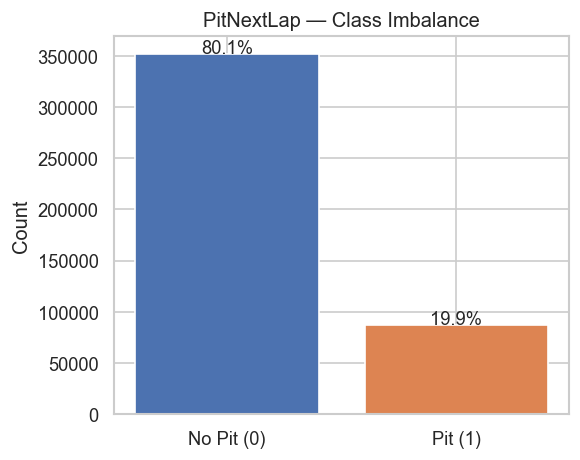

In [8]:
target_counts = train['PitNextLap'].value_counts()
target_pct    = train['PitNextLap'].value_counts(normalize=True) * 100

print('Target distribution:')
print(pd.DataFrame({'count': target_counts, 'pct': target_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['No Pit (0)', 'Pit (1)'], target_counts.values,
       color=['#4C72B0', '#DD8452'])
for i, (v, p) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, v + 1000, f'{p:.1f}%', ha='center', fontsize=11)
ax.set_title('PitNextLap — Class Imbalance')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Target rate by year — check for yearly inconsistency (flagged in discussions)
train.groupby('Year')['PitNextLap'].agg(['mean', 'count']).rename(
    columns={'mean': 'pit_rate', 'count': 'rows'}
).assign(pit_rate=lambda df: (df.pit_rate * 100).round(2))

,pit_rate,rows
Year,,
2022,26.6500,82989
2023,0.9600,136147
2024,29.5300,127110
2025,28.4400,92894


## 4. Categorical Features

In [10]:
cat_cols = ['Compound', 'Race', 'Driver', 'Year']

for col in cat_cols:
    n_unique = train[col].nunique()
    top5 = train[col].value_counts().head(5)
    pit_rate = train.groupby(col)['PitNextLap'].mean().sort_values(ascending=False).head(5)
    print(f'\n--- {col} ({n_unique} unique values) ---')
    print('Top 5 by count:')
    print(top5.to_string())
    print('Top 5 by pit rate:')
    print((pit_rate * 100).round(2).to_string())


--- Compound (5 unique values) ---
Top 5 by count:
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Top 5 by pit rate:
Compound
HARD           32.7500
SOFT           19.3500
INTERMEDIATE   15.2300
MEDIUM         10.1100
WET             2.5100

--- Race (26 unique values) ---
Top 5 by count:
Race
Dutch Grand Prix          24462
Mexico City Grand Prix    23672
Pre-Season Testing        22492
Hungarian Grand Prix      22481
Monaco Grand Prix         21539
Top 5 by pit rate:
Race
Chinese Grand Prix   38.8600
Monaco Grand Prix    35.7400
Spanish Grand Prix   32.0000
Bahrain Grand Prix   28.7500
Belgian Grand Prix   28.0400

--- Driver (887 unique values) ---
Top 5 by count:
Driver
MAS    1682
RAI    1669
BAR    1656
BUT    1655
FIS    1651
Top 5 by pit rate:
Driver
VET   56.5500
MSC   47.3200
HAD   46.2100
STR   42.7500
ANT   41.0100

--- Year (4 unique values) ---
Top 5 by count:
Year
2023    136147
2024    127110


In [11]:
# Compound pit rate — key strategic signal
compound_stats = train.groupby('Compound').agg(
    pit_rate=('PitNextLap', 'mean'),
    count=('PitNextLap', 'count'),
    median_tyre_life=('TyreLife', 'median')
).sort_values('pit_rate', ascending=False)
compound_stats['pit_rate'] = (compound_stats['pit_rate'] * 100).round(2)
print(compound_stats)

              pit_rate   count  median_tyre_life
Compound                                        
HARD           32.7500  170518           17.0000
SOFT           19.3500   38744           10.0000
INTERMEDIATE   15.2300   17382           12.0000
MEDIUM         10.1100  211141           11.0000
WET             2.5100    1355            9.0000


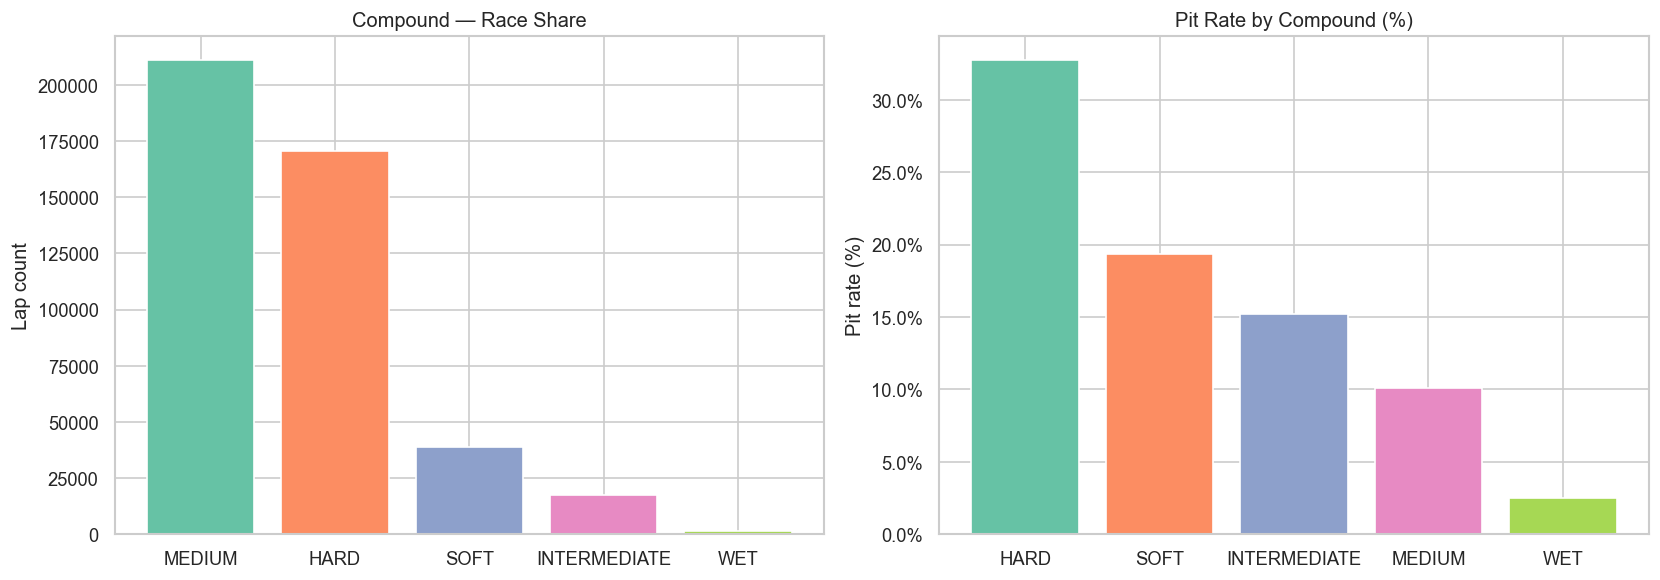

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compound distribution
compound_counts = train['Compound'].value_counts()
axes[0].bar(compound_counts.index, compound_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Compound — Race Share')
axes[0].set_ylabel('Lap count')

# Pit rate by compound
pit_by_compound = train.groupby('Compound')['PitNextLap'].mean().sort_values(ascending=False)
axes[1].bar(pit_by_compound.index, pit_by_compound.values * 100, color=sns.color_palette('Set2'))
axes[1].set_title('Pit Rate by Compound (%)')
axes[1].set_ylabel('Pit rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 5. Numerical Features

In [13]:
num_cols = ['LapNumber', 'Stint', 'TyreLife', 'Position']
train[num_cols].describe()

,LapNumber,Stint,TyreLife,Position
count,439140.0000,439140.0000,439140.0000,439140.0000
mean,23.1059,1.7891,14.1582,9.6303
std,16.9583,0.9502,9.8013,5.2788
min,1.0000,1.0000,1.0000,1.0000
25%,9.0000,1.0000,6.0000,5.0000
50%,19.0000,2.0000,12.0000,10.0000
75%,36.0000,2.0000,20.0000,14.0000
max,78.0000,8.0000,77.0000,20.0000


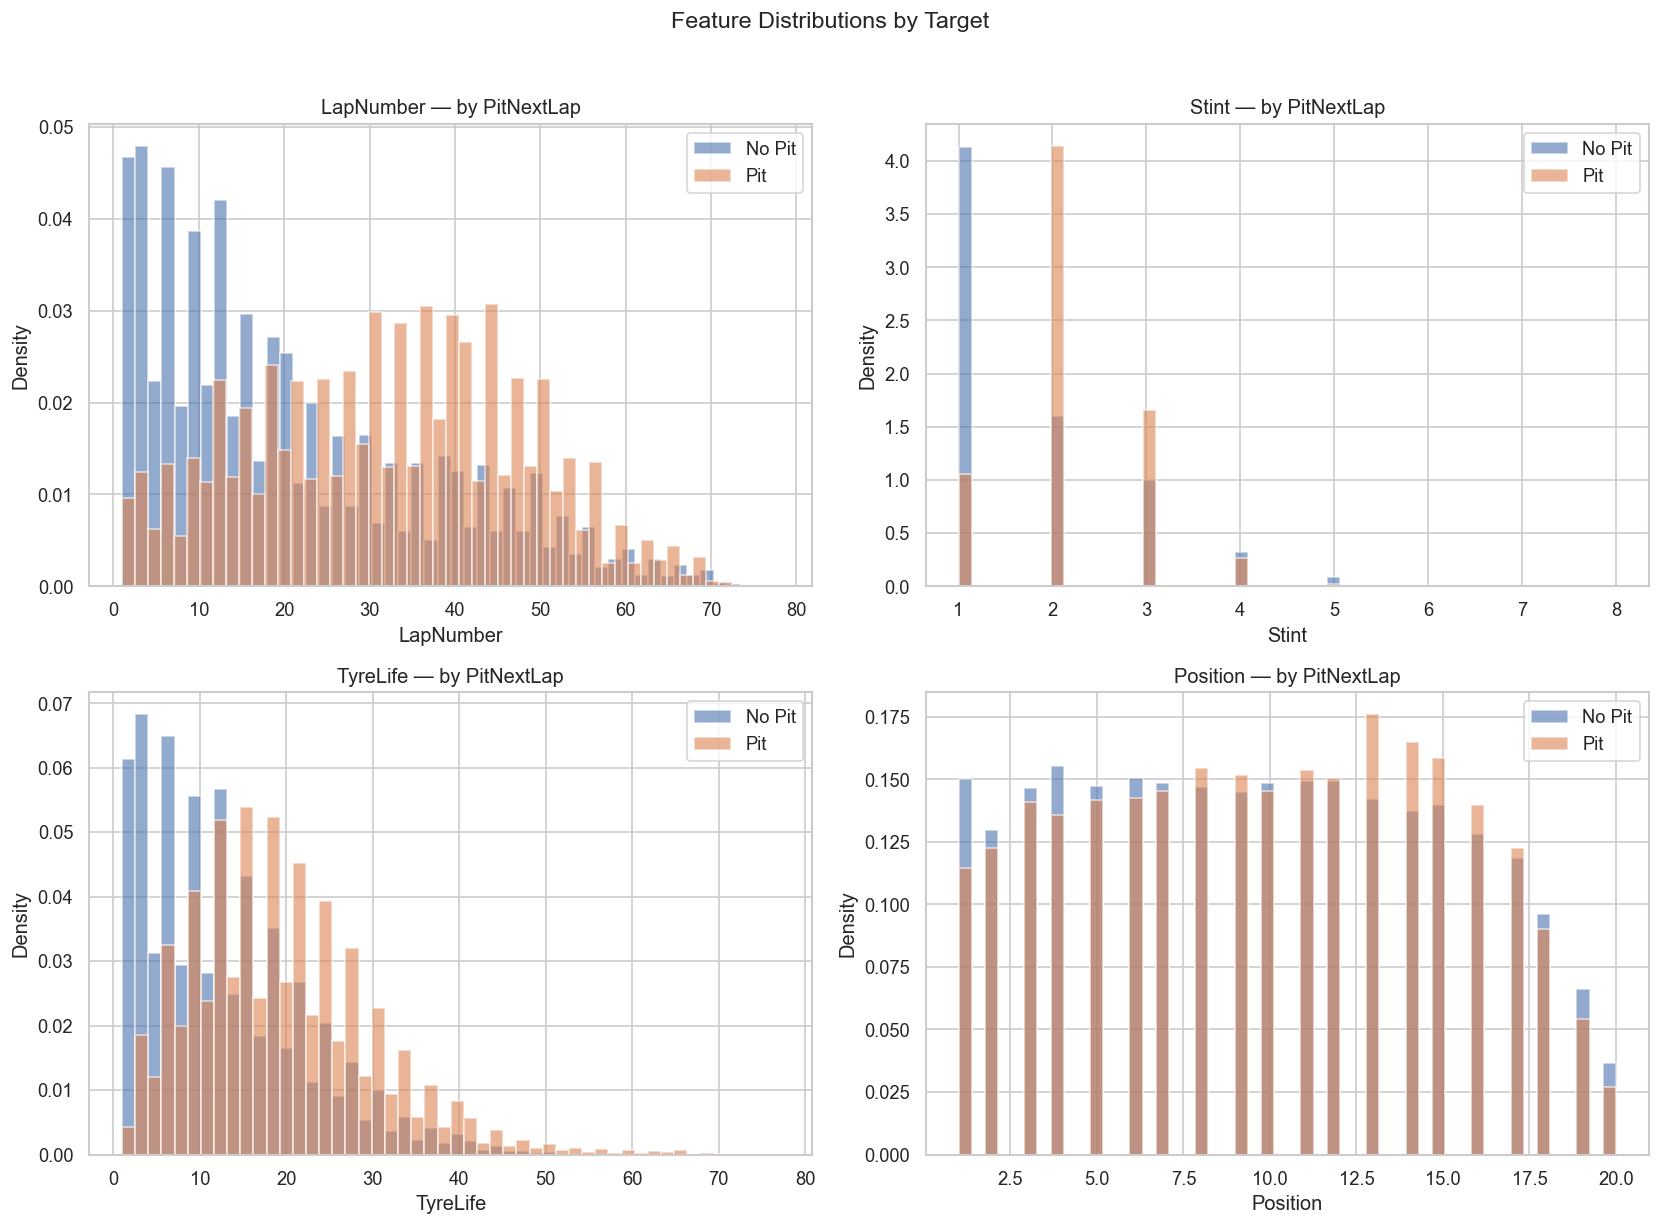

In [14]:
# Distribution of numerical features split by PitNextLap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), num_cols):
    for val, label, color in [(0, 'No Pit', '#4C72B0'), (1, 'Pit', '#DD8452')]:
        subset = train[train['PitNextLap'] == val][col]
        ax.hist(subset, bins=50, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(f'{col} — by PitNextLap')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Feature Distributions by Target', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 6. TyreLife — The Central Signal

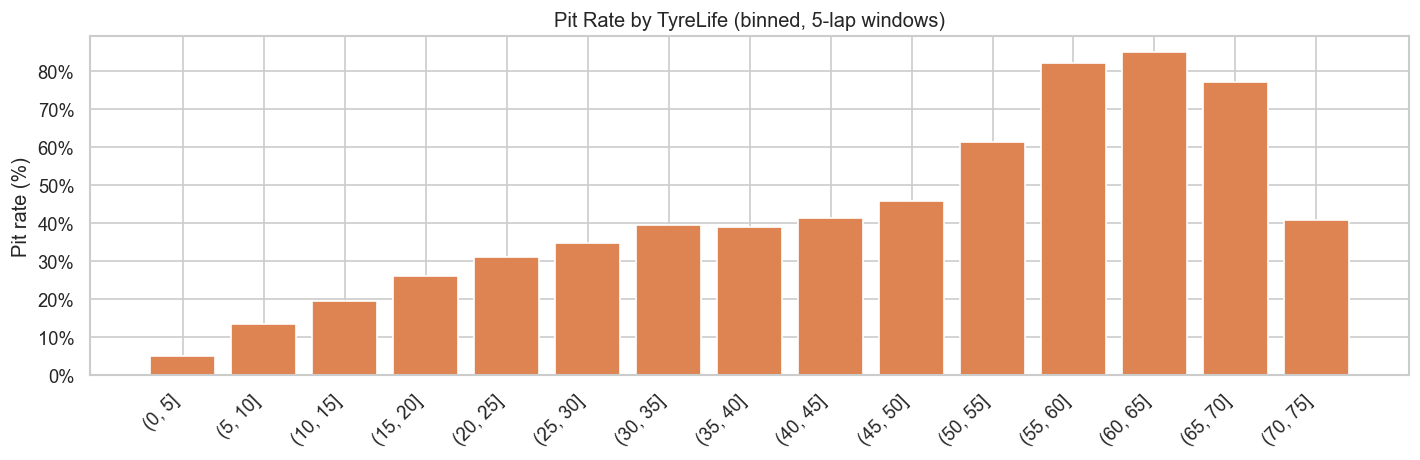

In [15]:
# Pit rate as a function of TyreLife — binned
train['TyreLife_bin'] = pd.cut(train['TyreLife'], bins=range(0, 80, 5))
tyre_pit = train.groupby('TyreLife_bin', observed=True)['PitNextLap'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(tyre_pit)), tyre_pit.values * 100, color='#DD8452')
ax.set_xticks(range(len(tyre_pit)))
ax.set_xticklabels([str(b) for b in tyre_pit.index], rotation=45, ha='right')
ax.set_title('Pit Rate by TyreLife (binned, 5-lap windows)')
ax.set_ylabel('Pit rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

train.drop(columns='TyreLife_bin', inplace=True)

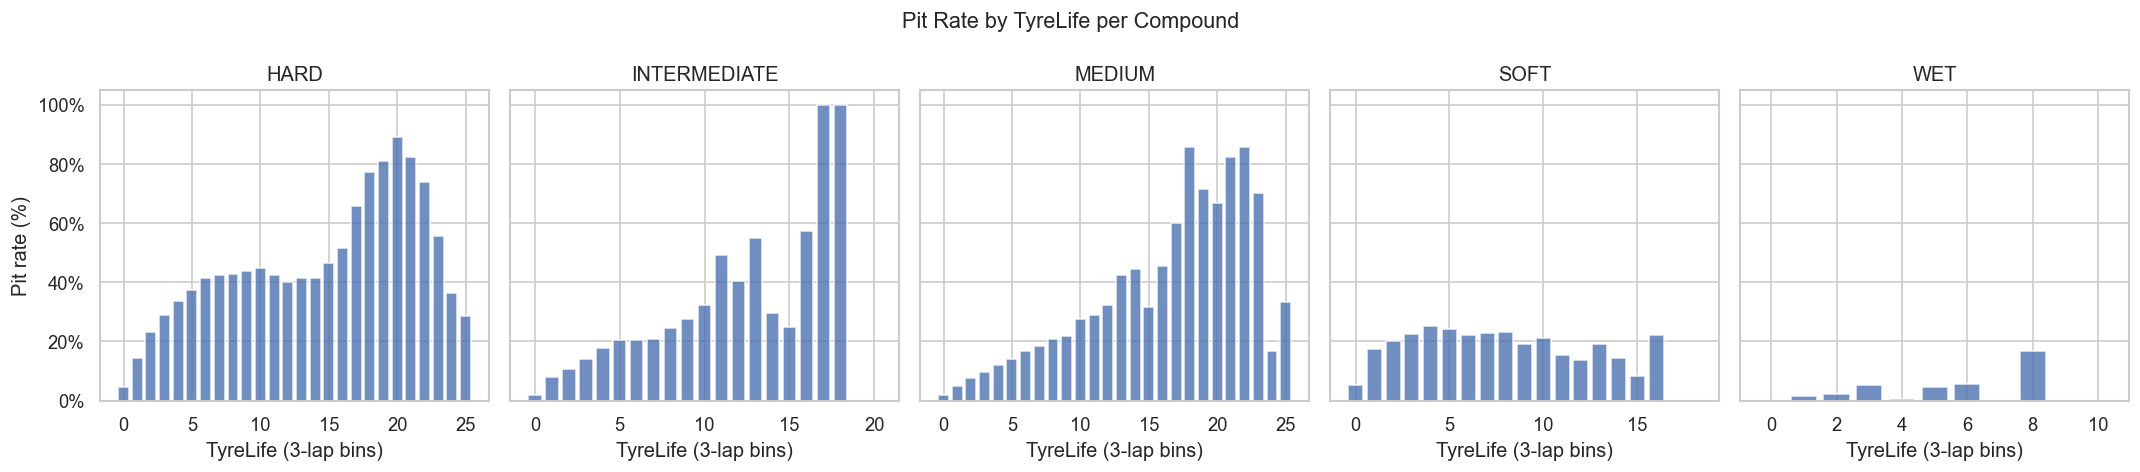

In [16]:
# TyreLife pit rate split by Compound
fig, axes = plt.subplots(1, train['Compound'].nunique(), figsize=(18, 4), sharey=True)

for ax, compound in zip(axes, sorted(train['Compound'].unique())):
    subset = train[train['Compound'] == compound].copy()
    subset['TyreLife_bin'] = pd.cut(subset['TyreLife'], bins=range(0, 80, 3))
    pit_rate = subset.groupby('TyreLife_bin', observed=True)['PitNextLap'].mean()
    ax.bar(range(len(pit_rate)), pit_rate.values * 100, color='#4C72B0', alpha=0.8)
    ax.set_title(f'{compound}')
    ax.set_xlabel('TyreLife (3-lap bins)')
    if ax == axes[0]:
        ax.set_ylabel('Pit rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Pit Rate by TyreLife per Compound', fontsize=13)
plt.tight_layout()
plt.show()

## 7. LapNumber & Race Context

In [17]:
# Total race length per race (max LapNumber)
race_lengths = train.groupby(['Year', 'Race'])['LapNumber'].max().reset_index()
race_lengths.columns = ['Year', 'Race', 'TotalLaps']
print(f'Race length range: {race_lengths.TotalLaps.min()} – {race_lengths.TotalLaps.max()} laps')
print(race_lengths.sort_values('TotalLaps', ascending=False).head(10).to_string(index=False))

Race length range: 45 – 78 laps
 Year                   Race  TotalLaps
 2023      Monaco Grand Prix         78
 2024      Monaco Grand Prix         78
 2023       Dutch Grand Prix         77
 2023     Spanish Grand Prix         76
 2025      Monaco Grand Prix         76
 2025   Hungarian Grand Prix         76
 2023   São Paulo Grand Prix         76
 2024       Dutch Grand Prix         76
 2024    Austrian Grand Prix         76
 2024 Mexico City Grand Prix         76


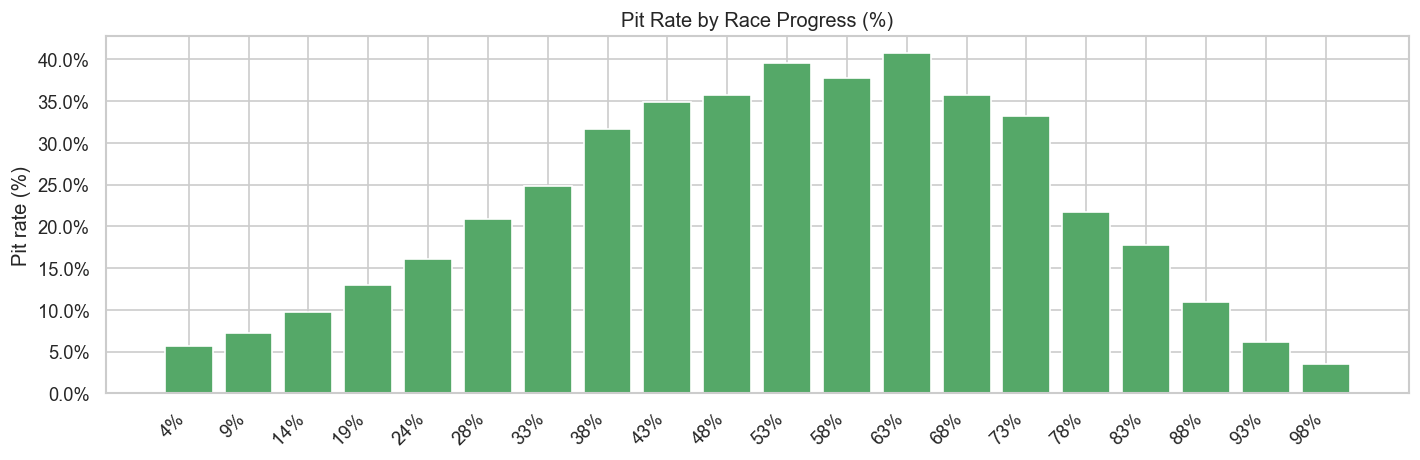

In [18]:
# Safe merge: drop TotalLaps/LapsRemaining if re-running
train = train.drop(columns=[c for c in ['TotalLaps', 'LapsRemaining'] if c in train.columns])
train = train.merge(race_lengths, on=['Year', 'Race'], how='left')
train['LapsRemaining'] = train['TotalLaps'] - train['LapNumber']

# RaceProgress already exists — use it directly
train['RaceProgress_bin'] = pd.cut(train['RaceProgress'], bins=20)
prog_pit = train.groupby('RaceProgress_bin', observed=True)['PitNextLap'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(prog_pit)), prog_pit.values * 100, color='#55A868')
ax.set_xticks(range(len(prog_pit)))
ax.set_xticklabels([f'{b.mid:.0%}' for b in prog_pit.index], rotation=45, ha='right')
ax.set_title('Pit Rate by Race Progress (%)')
ax.set_ylabel('Pit rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

train.drop(columns=['RaceProgress_bin'], inplace=True)

In [19]:
# Nobody pits in the final few laps — confirm the cliff
print('Pit rate for last 3 laps of race:')
print(train[train['LapsRemaining'] <= 3].groupby('LapsRemaining')['PitNextLap'].mean())

print('\nPit rate for laps 1–3 of race:')
print(train[train['LapNumber'] <= 3].groupby('LapNumber')['PitNextLap'].mean())

Pit rate for last 3 laps of race:
LapsRemaining
0   0.3523
1   0.2069
2   0.2178
3   0.2876
Name: PitNextLap, dtype: float64

Pit rate for laps 1–3 of race:
LapNumber
1   0.0464
2   0.0500
3   0.0550
Name: PitNextLap, dtype: float64


## 8. Position & Stint

In [20]:
# Pit rate by position group
train['PositionGroup'] = pd.cut(train['Position'], bins=[0,5,10,15,20], labels=['P1-5','P6-10','P11-15','P16-20'])
pos_pit = train.groupby('PositionGroup', observed=True)['PitNextLap'].mean()
print('Pit rate by position group:')
print((pos_pit * 100).round(2))
train.drop(columns='PositionGroup', inplace=True)

Pit rate by position group:
PositionGroup
P1-5     18.2500
P6-10    19.8900
P11-15   21.7700
P16-20   19.4700
Name: PitNextLap, dtype: float64


In [21]:
# Pit rate by stint number
stint_pit = train.groupby('Stint')['PitNextLap'].agg(['mean', 'count'])
stint_pit['mean'] = (stint_pit['mean'] * 100).round(2)
print('Pit rate by stint:')
print(stint_pit)

Pit rate by stint:
         mean   count
Stint                
1      5.9800  216288
2     39.1100  129536
3     29.3100   69238
4     17.1700   18903
5      5.3000    4281
6      1.9200     728
7      0.0000     116
8      2.0000      50


## 9. PitStop Column vs PitNextLap

In [22]:
# PitStop = 1 means this lap was a pit lap
# PitNextLap = 1 means the NEXT lap is a pit
# These should be consistent: PitStop[lap N] == PitNextLap[lap N-1]
print('PitStop vs PitNextLap crosstab:')
print(pd.crosstab(train['PitStop'], train['PitNextLap'], 
                  rownames=['PitStop (this lap)'], 
                  colnames=['PitNextLap (next lap)'],
                  normalize='all').round(4))

PitStop vs PitNextLap crosstab:
PitNextLap (next lap)  0.0000  1.0000
PitStop (this lap)                   
0                      0.6986  0.1652
1                      0.1024  0.0337


In [23]:
# Verify temporal consistency within a driver/race session
# Sort by driver, race, year, lap and check shift
train_sorted = train.sort_values(['Year', 'Race', 'Driver', 'LapNumber']).copy()
train_sorted['PitStop_next'] = train_sorted.groupby(
    ['Year', 'Race', 'Driver'])['PitStop'].shift(-1)

# When PitNextLap==1, PitStop on the next row should be 1
match_pct = (train_sorted['PitStop_next'] == train_sorted['PitNextLap']).mean()
print(f'PitNextLap ↔ next-row PitStop alignment: {match_pct:.2%}')

PitNextLap ↔ next-row PitStop alignment: 68.20%


## 9b. Pre-Engineered Columns: LapTime_Delta, Cumulative_Degradation, Position_Change

In [24]:
# Understand what these columns actually represent
new_cols = ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'Position_Change']
print('=== Descriptive stats for pre-engineered columns ===')
print(train[new_cols].describe().round(3))

=== Descriptive stats for pre-engineered columns ===
       LapTime (s)  LapTime_Delta  Cumulative_Degradation  Position_Change
count  439140.0000    439140.0000             439140.0000      439140.0000
mean       90.9490        -3.7700                -25.7220           0.1020
std        19.7730        43.9460                 54.7670           4.0070
min        67.6940     -2403.8950               -274.5640         -18.0000
25%        82.6210        -8.8840                -46.5660          -1.0000
50%        90.5210        -0.2950                -20.9940           0.0000
75%        98.4710         0.1150                 -6.1990           2.0000
max      2507.6070      2423.9320               2412.0260          18.0000


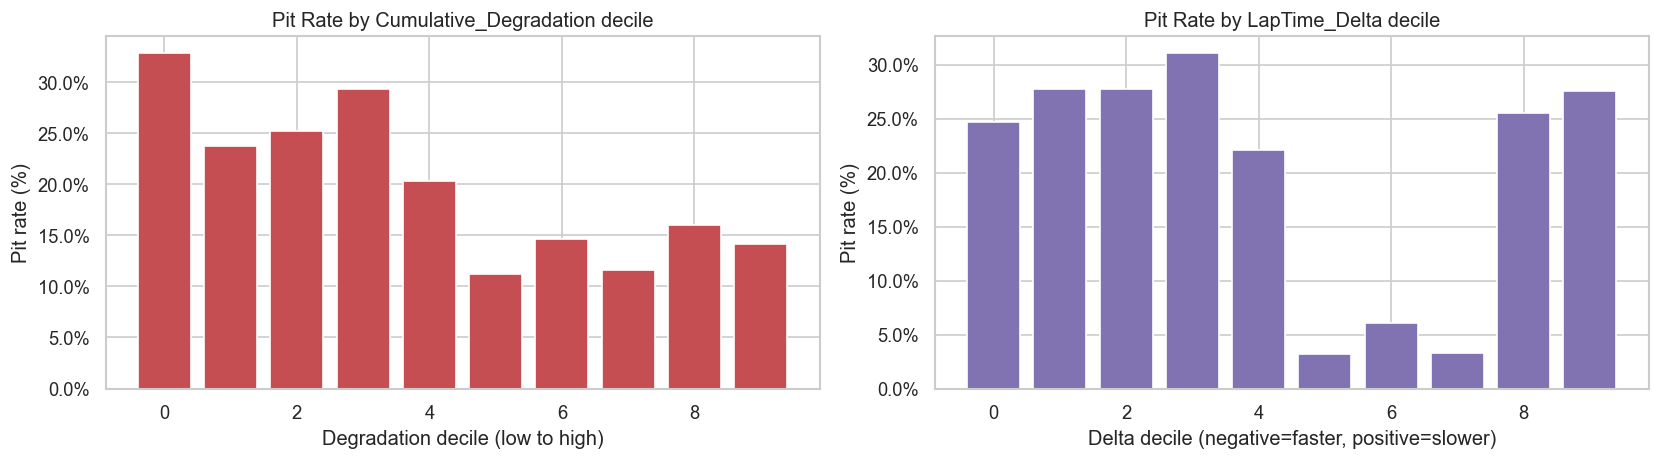

In [25]:
# Pit rate by binned Cumulative_Degradation
train['CumDeg_bin'] = pd.qcut(train['Cumulative_Degradation'], q=10, duplicates='drop')
deg_pit = train.groupby('CumDeg_bin', observed=True)['PitNextLap'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(len(deg_pit)), deg_pit.values * 100, color='#C44E52')
axes[0].set_title('Pit Rate by Cumulative_Degradation decile')
axes[0].set_xlabel('Degradation decile (low to high)')
axes[0].set_ylabel('Pit rate (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())

# LapTime_Delta vs pit
train['Delta_bin'] = pd.qcut(train['LapTime_Delta'], q=10, duplicates='drop')
delta_pit = train.groupby('Delta_bin', observed=True)['PitNextLap'].mean()
axes[1].bar(range(len(delta_pit)), delta_pit.values * 100, color='#8172B2')
axes[1].set_title('Pit Rate by LapTime_Delta decile')
axes[1].set_xlabel('Delta decile (negative=faster, positive=slower)')
axes[1].set_ylabel('Pit rate (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

train.drop(columns=['CumDeg_bin', 'Delta_bin'], inplace=True)

In [26]:
# Pre-Season Testing — is it in the data and should we keep it?
print('Races in dataset:')
print(sorted(train['Race'].unique()))
print(f'\nPre-Season Testing rows: {(train["Race"] == "Pre-Season Testing").sum()}')
print(f'Pre-Season Testing pit rate: {train[train["Race"] == "Pre-Season Testing"]["PitNextLap"].mean():.2%}')

Races in dataset:
['Abu Dhabi Grand Prix', 'Australian Grand Prix', 'Austrian Grand Prix', 'Azerbaijan Grand Prix', 'Bahrain Grand Prix', 'Belgian Grand Prix', 'British Grand Prix', 'Canadian Grand Prix', 'Chinese Grand Prix', 'Dutch Grand Prix', 'Emilia Romagna Grand Prix', 'French Grand Prix', 'Hungarian Grand Prix', 'Italian Grand Prix', 'Japanese Grand Prix', 'Las Vegas Grand Prix', 'Mexico City Grand Prix', 'Miami Grand Prix', 'Monaco Grand Prix', 'Pre-Season Testing', 'Qatar Grand Prix', 'Saudi Arabian Grand Prix', 'Singapore Grand Prix', 'Spanish Grand Prix', 'São Paulo Grand Prix', 'United States Grand Prix']

Pre-Season Testing rows: 22492
Pre-Season Testing pit rate: 14.65%


In [27]:
# Point-biserial correlations with target — all numeric features
from scipy.stats import pointbiserialr

feature_cols = ['LapNumber', 'Stint', 'TyreLife', 'Position',
                'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
                'RaceProgress', 'Position_Change', 'LapsRemaining', 'TotalLaps']

corrs = {}
for col in feature_cols:
    if col in train.columns:
        r, p = pointbiserialr(train[col].dropna(), train.loc[train[col].notna(), 'PitNextLap'])
        corrs[col] = {'correlation': round(r, 4), 'p_value': p}

corr_df = pd.DataFrame(corrs).T.sort_values('correlation', key=abs, ascending=False)
print(corr_df)

                        correlation  p_value
TyreLife                     0.2735   0.0000
LapNumber                    0.2671   0.0000
LapsRemaining               -0.2612   0.0000
Stint                        0.1982   0.0000
RaceProgress                 0.1855   0.0000
Cumulative_Degradation      -0.1674   0.0000
Position_Change              0.0462   0.0000
LapTime (s)                 -0.0341   0.0000
Position                     0.0213   0.0000
LapTime_Delta               -0.0049   0.0010
TotalLaps                    0.0012   0.4411


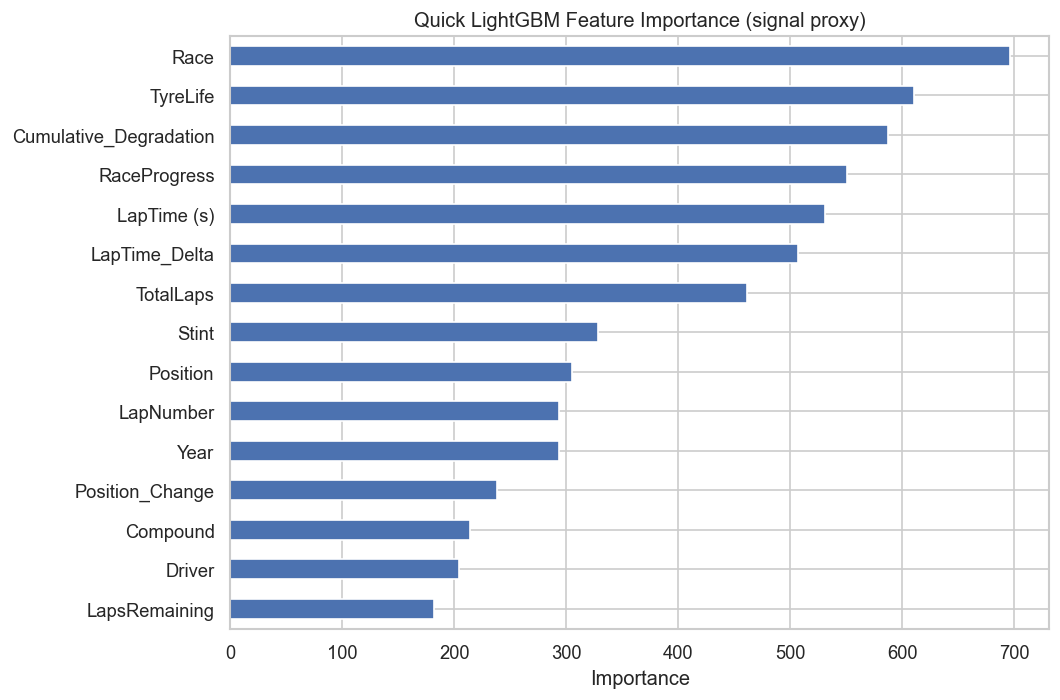


Top 5 features:
Race                      696
TyreLife                  610
Cumulative_Degradation    587
RaceProgress              551
LapTime (s)               531
dtype: int32


In [28]:
# Quick LightGBM importance check (no tuning, just signal ranking)
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

quick = train.copy()
for col in ['Compound', 'Race', 'Driver']:
    quick[col] = LabelEncoder().fit_transform(quick[col].astype(str))

features = ['LapNumber', 'Stint', 'TyreLife', 'Position',
            'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
            'RaceProgress', 'Position_Change', 'LapsRemaining', 'TotalLaps',
            'Compound', 'Race', 'Driver', 'Year']

# Keep only features that exist in train
features = [f for f in features if f in quick.columns]

clf = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1)
clf.fit(quick[features], quick['PitNextLap'])

imp = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
imp.plot(kind='barh', ax=ax, color='#4C72B0')
ax.invert_yaxis()
ax.set_title('Quick LightGBM Feature Importance (signal proxy)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(imp.head())

## 11. Train vs Test Distribution Check

In [32]:
# Check for distribution shift between train and test
num_check = ['LapNumber', 'TyreLife', 'Position', 'Stint',
             'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
             'RaceProgress', 'Position_Change']

for col in num_check:
    if col in train.columns and col in test.columns:
        t_mean = train[col].mean()
        te_mean = test[col].mean()
        t_std = train[col].std()
        te_std = test[col].std()
        print(f'{col:25s} | train mean={t_mean:8.2f} std={t_std:7.2f} | test mean={te_mean:8.2f} std={te_std:7.2f}')

LapNumber                 | train mean=   23.11 std=  16.96 | test mean=   23.05 std=  17.00
TyreLife                  | train mean=   14.16 std=   9.80 | test mean=   14.16 std=   9.85
Position                  | train mean=    9.63 std=   5.28 | test mean=    9.60 std=   5.27
Stint                     | train mean=    1.79 std=   0.95 | test mean=    1.78 std=   0.95
LapTime (s)               | train mean=   90.95 std=  19.77 | test mean=   90.99 std=  20.86
LapTime_Delta             | train mean=   -3.77 std=  43.95 | test mean=   -3.58 std=  40.35
Cumulative_Degradation    | train mean=  -25.72 std=  54.77 | test mean=  -25.85 std=  54.92
RaceProgress              | train mean=    0.34 std=   0.25 | test mean=    0.34 std=   0.25
Position_Change           | train mean=    0.10 std=   4.01 | test mean=    0.11 std=   4.02


In [33]:
# Compound split in train vs test
print('Compound — train vs test share:')
comp_train = train['Compound'].value_counts(normalize=True).rename('train')
comp_test  = test['Compound'].value_counts(normalize=True).rename('test')
print(pd.concat([comp_train, comp_test], axis=1).round(3))

Compound — train vs test share:
              train   test
Compound                  
MEDIUM       0.4810 0.4830
HARD         0.3880 0.3860
SOFT         0.0880 0.0880
INTERMEDIATE 0.0400 0.0390
WET          0.0030 0.0030


In [34]:
# Year split in train vs test
print('Year — train vs test:')
print(pd.DataFrame({
    'train': train['Year'].value_counts().sort_index(),
    'test':  test['Year'].value_counts().sort_index()
}))

Year — train vs test:
       train   test
Year               
2022   82989  35348
2023  136147  58160
2024  127110  54532
2025   92894  40125


In [35]:
train.groupby(['Year', 'Race']).agg(
    TotalLaps=('LapNumber', 'max'),
    Drivers=('Driver', 'nunique'),
    Rows=('id', 'count')
).reset_index().sort_values(['Year', 'TotalLaps']).to_string(index=False)

' Year                      Race  TotalLaps  Drivers  Rows\n 2022      Las Vegas Grand Prix         50       17    41\n 2022       Japanese Grand Prix         52      180   903\n 2022  Saudi Arabian Grand Prix         53      465  4518\n 2022        Chinese Grand Prix         54        7     8\n 2022          Qatar Grand Prix         55       24    86\n 2022     Azerbaijan Grand Prix         58      275  2564\n 2022        Belgian Grand Prix         60      224  1837\n 2022  United States Grand Prix         60      426  3485\n 2022      Abu Dhabi Grand Prix         61       20    56\n 2022          Miami Grand Prix         63      441  4320\n 2022        Bahrain Grand Prix         68      424  4034\n 2022         French Grand Prix         68      246  3141\n 2022      Singapore Grand Prix         68      181  1960\n 2022        Spanish Grand Prix         68      459  4769\n 2022        British Grand Prix         69      276  2532\n 2022 Emilia Romagna Grand Prix         69      402  43

In [36]:
# Drivers with fewer laps than the race winner (DNFs, retirements)
lap_counts = train.groupby(['Year', 'Race', 'Driver'])['LapNumber'].max().reset_index()
lap_counts.columns = ['Year', 'Race', 'Driver', 'MaxLap']
race_max = lap_counts.groupby(['Year', 'Race'])['MaxLap'].max().reset_index()
race_max.columns = ['Year', 'Race', 'RaceMax']
merged = lap_counts.merge(race_max, on=['Year', 'Race'])
dnfs = merged[merged['MaxLap'] < merged['RaceMax']].copy()
dnfs['LapsDiff'] = dnfs['RaceMax'] - dnfs['MaxLap']
print(f'Total DNF-like entries: {len(dnfs)}')
print(f'Races affected: {dnfs.groupby(["Year","Race"]).ngroups}')
print(dnfs.groupby(['Year','Race'])['Driver'].count().reset_index().rename(
    columns={'Driver':'DNF_drivers'}).sort_values('DNF_drivers', ascending=False).head(10).to_string(index=False))

Total DNF-like entries: 40693
Races affected: 104
 Year                     Race  DNF_drivers
 2023         Miami Grand Prix          855
 2023     Abu Dhabi Grand Prix          792
 2023       Italian Grand Prix          747
 2023       Spanish Grand Prix          728
 2023       Bahrain Grand Prix          716
 2023     Las Vegas Grand Prix          646
 2023       Pre-Season Testing          622
 2023 United States Grand Prix          614
 2023      Canadian Grand Prix          588
 2023     Hungarian Grand Prix          577
